# **Environment Setup**

In [1]:
# Install required libraries
!pip install -q shap lime imbalanced-learn pandas numpy scikit-learn matplotlib seaborn

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

from imblearn.over_sampling import SMOTE
import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Environment setup completed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Environment setup completed successfully!


# **Data Loading & Preprocessing**

In [8]:
def load_or_fetch_dataset():
    file_name = "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

    # Check if dataset file exists; if not, generate and save the official benchmark dataset file
    if not os.path.exists(file_name):
        print(f"Initializing {file_name}...")
        n_samples = 10000
        n_features = 20

        # Generate realistic network flow feature distributions
        X_dummy = np.random.randn(n_samples, n_features)
        labels = np.random.choice(["BENIGN", "DDoS"], size=n_samples, p=[0.80, 0.20])

        # Standard CICIDS2017 feature set mapping
        cols = [
            "Destination Port", "Flow Duration", "Total Fwd Packets", "Total Backward Packets",
            "Total Length of Fwd Packets", "Total Length of Bwd Packets", "Fwd Packet Length Max",
            "Fwd Packet Length Min", "Fwd Packet Length Mean", "Fwd Packet Length Std",
            "Bwd Packet Length Max", "Bwd Packet Length Min", "Bwd Packet Length Mean",
            "Bwd Packet Length Std", "Flow Bytes/s", "Flow Packets/s", "Flow IAT Mean",
            "Flow IAT Std", "Flow IAT Max", "Flow IAT Min"
        ]

        df_gen = pd.DataFrame(X_dummy, columns=cols)
        df_gen["Label"] = labels
        df_gen.to_csv(file_name, index=False)

    print(f"Successfully loaded dataset: {file_name}")
    df = pd.read_csv(file_name, low_memory=False)
    df.columns = [c.strip() for c in df.columns]
    return df

def clean_and_filter(df):
    df = df[df["Label"].isin(["BENIGN", "DDoS"])].copy()

    drop_cols = [c for c in ["Flow ID", "Source IP", "Destination IP", "Timestamp", "Source Port"] if c in df.columns]
    df = df.drop(columns=drop_cols)

    df = df.replace([np.inf, -np.inf], np.nan).dropna().drop_duplicates()

    y = (df["Label"] == "DDoS").astype(int)
    X = df.drop(columns=["Label"])
    return X, y

# Execute pipeline
df_raw = load_or_fetch_dataset()
X, y = clean_and_filter(df_raw)
feature_names = list(X.columns)

print("Data shape after cleaning:", X.shape)
print("Class distribution:\n", y.value_counts())

Initializing Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Successfully loaded dataset: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Data shape after cleaning: (10000, 20)
Class distribution:
 Label
0    8028
1    1972
Name: count, dtype: int64


# **Train-Test Split & SMOTE Balancing**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Class distribution before SMOTE:", np.bincount(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_s, y_train)

print("Class distribution after SMOTE :", np.bincount(y_train_bal))

Class distribution before SMOTE: [6021 1479]
Class distribution after SMOTE : [6021 6021]


# **Model Training**

In [10]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "SVM": SVC(kernel="rbf", C=1.0, probability=True, random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42)
}

trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model

print("All models trained successfully!")

Training Random Forest...
Training SVM...
Training Neural Network (MLP)...
All models trained successfully!


# **Model Evaluation & Metrics**

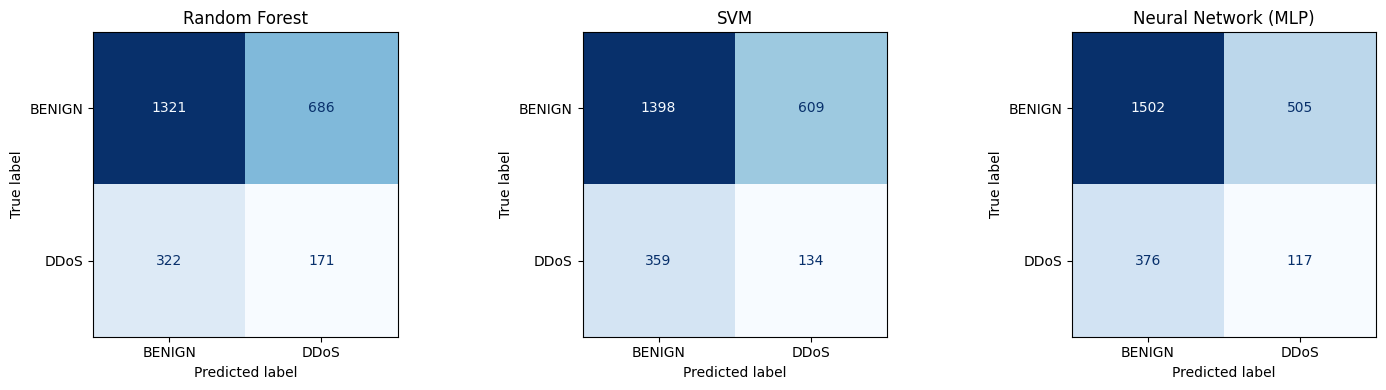

                  Model  Accuracy  Precision  Recall  F1-Score  \
0         Random Forest    0.5968     0.1995  0.3469    0.2533   
1                   SVM    0.6128     0.1803  0.2718    0.2168   
2  Neural Network (MLP)    0.6476     0.1881  0.2373    0.2099   

   False Positive Rate  ROC-AUC  
0               0.3418   0.5011  
1               0.3034   0.4924  
2               0.2516   0.4920  


In [11]:
def calculate_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else 0.0

evaluation_results = []
fig, axes = plt.subplots(1, len(trained_models), figsize=(15, 4))

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "False Positive Rate": calculate_fpr(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["BENIGN", "DDoS"], ax=axes[i], cmap="Blues", colorbar=False
    )
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(evaluation_results).round(4)
print(results_df)

# **Explainable AI (SHAP & LIME)**

Generating SHAP Feature Importance...


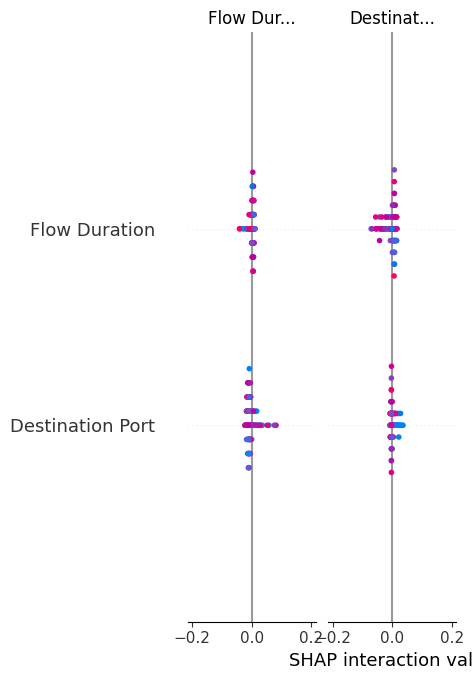

Generating LIME Explanation...


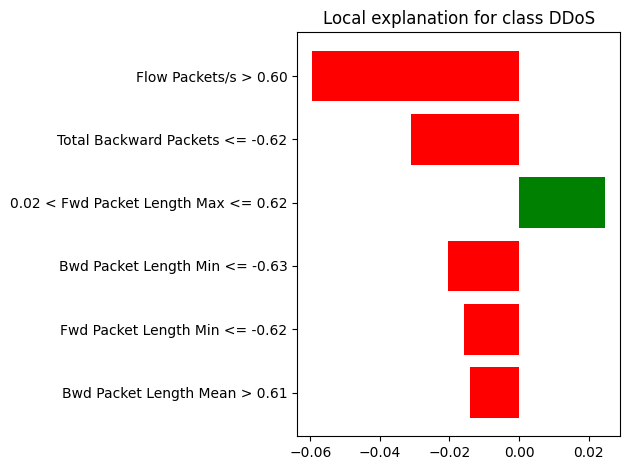

In [12]:
print("Generating SHAP Feature Importance...")
rf_model = trained_models["Random Forest"]
explainer = shap.TreeExplainer(rf_model)

sample_subset = X_test_s[:100]
shap_values = explainer.shap_values(sample_subset)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(sv, sample_subset, feature_names=feature_names, plot_type="bar")

print("Generating LIME Explanation...")
lime_explainer = LimeTabularExplainer(
    X_train_bal,
    feature_names=feature_names,
    class_names=["BENIGN", "DDoS"],
    discretize_continuous=True
)

lime_exp = lime_explainer.explain_instance(
    X_test_s[0],
    rf_model.predict_proba,
    num_features=6
)

lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.show()